In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.style.use("seaborn-v0_8")


In [4]:
def fold_ode(t, x, r):
    return r - x**2

def simulate_fold(r_values, x0=0.0, t_span=(0.0, 50.0), n_points=1000):
    t_eval = np.linspace(t_span[0], t_span[1], n_points)
    trajectories = []
    for r in r_values:
        sol = solve_ivp(lambda t, x: fold_ode(t, x, r),
                        t_span, [x0], t_eval=t_eval,
                        rtol=1e-8, atol=1e-8)
        trajectories.append(sol.y[0])
    return t_eval, np.array(trajectories)


In [5]:
def hopf_ode(t, z, r):
    x, y = z
    dx = r*x - y - x*(x**2 + y**2)
    dy = x + r*y - y*(x**2 + y**2)
    return [dx, dy]

def simulate_hopf(r_values, z0=(0.1, 0.0), t_span=(0.0, 100.0), n_points=2000):
    t_eval = np.linspace(t_span[0], t_span[1], n_points)
    trajectories = []
    for r in r_values:
        sol = solve_ivp(lambda t, z: hopf_ode(t, z, r),
                        t_span, z0, t_eval=t_eval,
                        rtol=1e-8, atol=1e-8)
        x, y = sol.y
        amp = np.sqrt(x**2 + y**2)
        trajectories.append(amp)
    return t_eval, np.array(trajectories)


In [6]:
def potential_force(x, r):
    return r*x - x**3

def simulate_noise_escape(r_values, x0=0.0, dt=0.01, n_steps=5000, sigma=0.1, seed=0):
    rng = np.random.default_rng(seed)
    t = np.arange(n_steps) * dt
    trajectories = []
    for r in r_values:
        x = np.zeros(n_steps)
        x[0] = x0
        for k in range(1, n_steps):
            drift = potential_force(x[k-1], r)
            noise = sigma * np.sqrt(dt) * rng.normal()
            x[k] = x[k-1] + drift*dt + noise
        trajectories.append(x)
    return t, np.array(trajectories)


In [7]:
def accr_drift(x, t=None):
    if t is None:
        return np.gradient(x)
    else:
        return np.gradient(x, t)

def accr_curvature(x, t=None):
    d = accr_drift(x, t)
    if t is None:
        return np.gradient(d)
    else:
        return np.gradient(d, t)

def accr_instability(x, t=None):
    d = accr_drift(x, t)
    c = accr_curvature(x, t)
    return np.abs(d) + np.abs(c)

def accr_summary(trajectories, t):
    drift_list = []
    curv_list = []
    inst_list = []
    for x in trajectories:
        d = accr_drift(x, t)
        c = accr_curvature(x, t)
        inst = np.abs(d) + np.abs(c)
        drift_list.append(d)
        curv_list.append(c)
        inst_list.append(inst)
    drift_arr = np.array(drift_list)
    curv_arr = np.array(curv_list)
    inst_arr = np.array(inst_list)
    return {
        "drift_mean": drift_arr.mean(axis=0),
        "curv_mean": curv_arr.mean(axis=0),
        "inst_mean": inst_arr.mean(axis=0),
        "drift_var": drift_arr.var(axis=0),
        "curv_var": curv_arr.var(axis=0),
        "inst_var": inst_arr.var(axis=0),
    }


In [8]:
r_fold = np.linspace(0.5, 0.0, 10)
t_fold, traj_fold = simulate_fold(r_fold, x0=0.0)

r_hopf = np.linspace(-0.2, 0.2, 10)
t_hopf, traj_hopf = simulate_hopf(r_hopf, z0=(0.1, 0.0))

r_noise = np.linspace(0.0, 0.8, 10)
t_noise, traj_noise = simulate_noise_escape(r_noise, x0=0.0)


In [9]:
summary_fold = accr_summary(traj_fold, t_fold)
summary_hopf = accr_summary(traj_hopf, t_hopf)
summary_noise = accr_summary(traj_noise, t_noise)


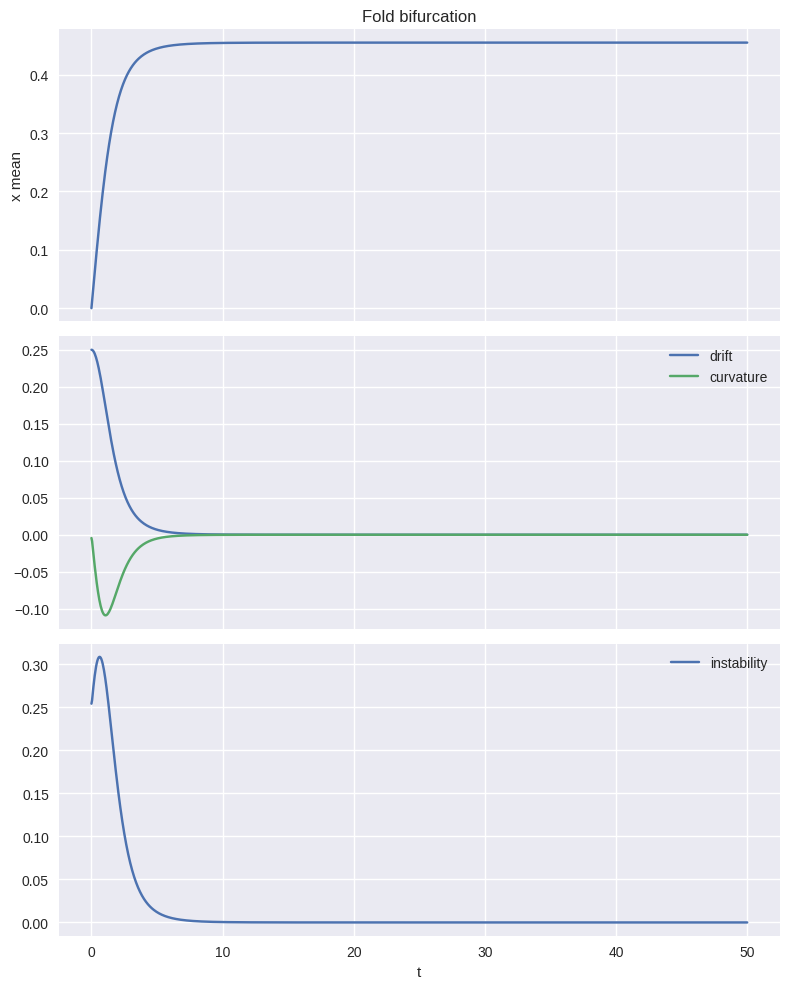

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].plot(t_fold, traj_fold.mean(axis=0))
axes[0].set_ylabel("x mean")
axes[0].set_title("Fold bifurcation")

axes[1].plot(t_fold, summary_fold["drift_mean"], label="drift")
axes[1].plot(t_fold, summary_fold["curv_mean"], label="curvature")
axes[1].legend()

axes[2].plot(t_fold, summary_fold["inst_mean"], label="instability")
axes[2].legend()
axes[2].set_xlabel("t")

plt.tight_layout()
plt.show()


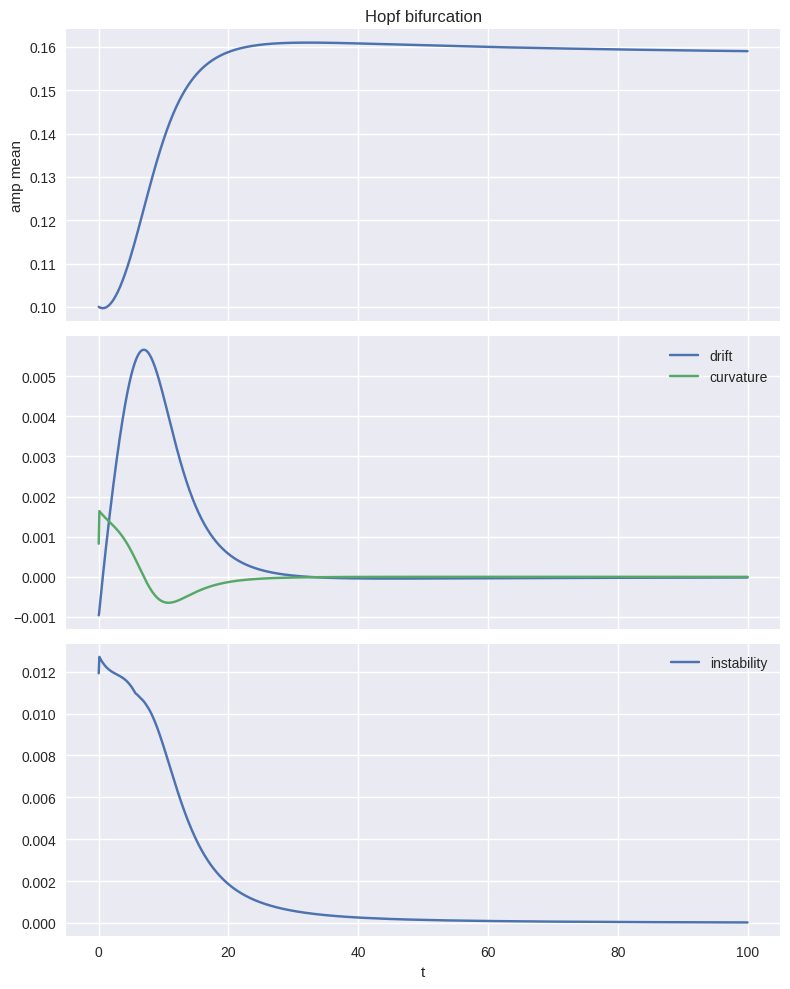

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].plot(t_hopf, traj_hopf.mean(axis=0))
axes[0].set_ylabel("amp mean")
axes[0].set_title("Hopf bifurcation")

axes[1].plot(t_hopf, summary_hopf["drift_mean"], label="drift")
axes[1].plot(t_hopf, summary_hopf["curv_mean"], label="curvature")
axes[1].legend()

axes[2].plot(t_hopf, summary_hopf["inst_mean"], label="instability")
axes[2].legend()
axes[2].set_xlabel("t")

plt.tight_layout()
plt.show()


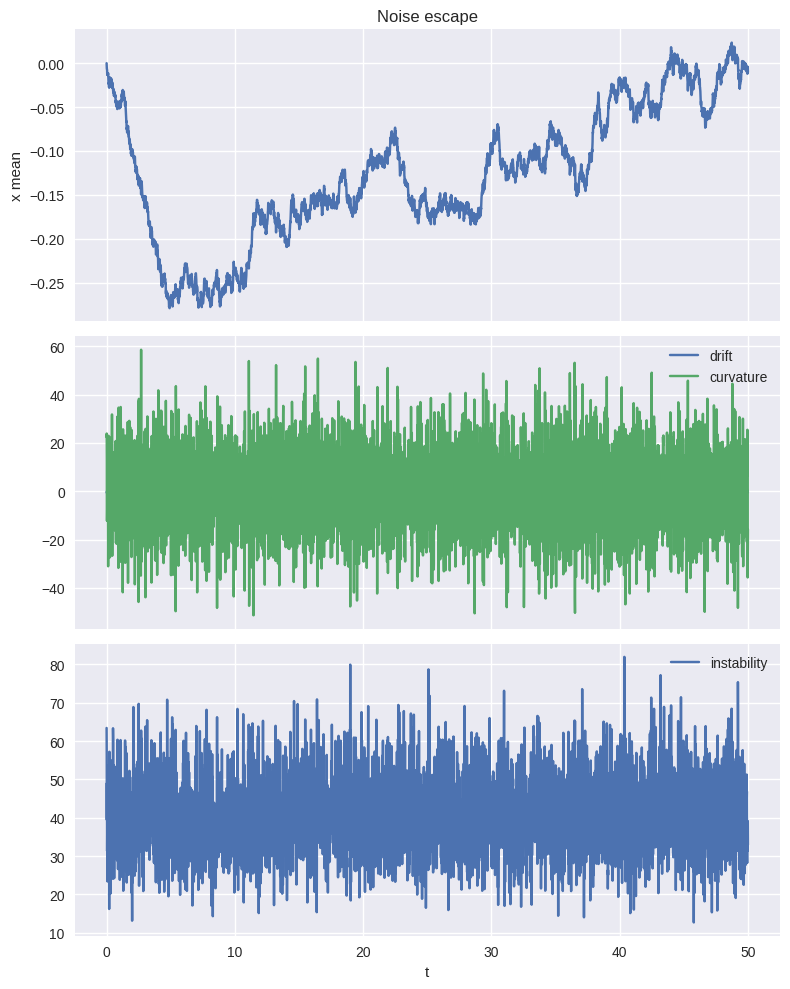

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].plot(t_noise, traj_noise.mean(axis=0))
axes[0].set_ylabel("x mean")
axes[0].set_title("Noise escape")

axes[1].plot(t_noise, summary_noise["drift_mean"], label="drift")
axes[1].plot(t_noise, summary_noise["curv_mean"], label="curvature")
axes[1].legend()

axes[2].plot(t_noise, summary_noise["inst_mean"], label="instability")
axes[2].legend()
axes[2].set_xlabel("t")

plt.tight_layout()
plt.show()


In [13]:
def summarize_system(name, t, summary):
    print(f"=== {name} ===")
    inst = summary["inst_mean"]
    drift = summary["drift_mean"]
    curv = summary["curv_mean"]

    # Simple scalar summaries
    print(f"instability mean (overall): {inst.mean():.4f}")
    print(f"instability max:            {inst.max():.4f}")
    print(f"drift mean (abs):           {np.abs(drift).mean():.4f}")
    print(f"curvature mean (abs):       {np.abs(curv).mean():.4f}")

    # Early-warning style: compare first vs last 10 percent
    n = len(t)
    k = max(1, n // 10)
    inst_early = inst[:k].mean()
    inst_late = inst[-k:].mean()
    print(f"instability early mean:     {inst_early:.4f}")
    print(f"instability late mean:      {inst_late:.4f}")
    print(f"ratio late / early:         {inst_late / inst_early if inst_early != 0 else np.nan:.4f}")
    print()

summarize_system("Fold bifurcation", t_fold, summary_fold)
summarize_system("Hopf bifurcation", t_hopf, summary_hopf)
summarize_system("Noise escape", t_noise, summary_noise)


=== Fold bifurcation ===
instability mean (overall): 0.0142
instability max:            0.3088
drift mean (abs):           0.0092
curvature mean (abs):       0.0050
instability early mean:     0.1387
instability late mean:      0.0000
ratio late / early:         0.0000

=== Hopf bifurcation ===
instability mean (overall): 0.0017
instability max:            0.0127
drift mean (abs):           0.0006
curvature mean (abs):       0.0001
instability early mean:     0.0111
instability late mean:      0.0000
ratio late / early:         0.0027

=== Noise escape ===
instability mean (overall): 40.4998
instability max:            81.9765
drift mean (abs):           0.1783
curvature mean (abs):       12.7548
instability early mean:     40.8242
instability late mean:      40.2272
ratio late / early:         0.9854



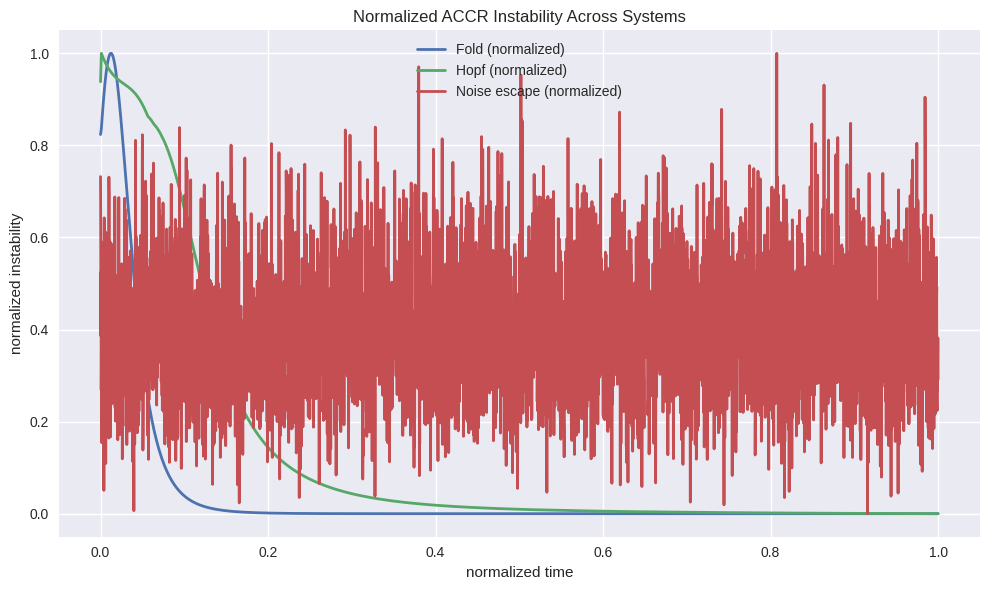

In [15]:
def normalize_curve(t, y):
    # normalize time to [0, 1]
    t_norm = (t - t.min()) / (t.max() - t.min())
    # normalize y to [0, 1] (avoid divide by zero)
    y_min = y.min()
    y_max = y.max()
    if y_max == y_min:
        y_norm = np.zeros_like(y)
    else:
        y_norm = (y - y_min) / (y_max - y_min)
    return t_norm, y_norm

t_fold_n, inst_fold_n = normalize_curve(t_fold, summary_fold["inst_mean"])
t_hopf_n, inst_hopf_n = normalize_curve(t_hopf, summary_hopf["inst_mean"])
t_noise_n, inst_noise_n = normalize_curve(t_noise, summary_noise["inst_mean"])

plt.figure(figsize=(10, 6))

plt.plot(t_fold_n, inst_fold_n, label="Fold (normalized)", linewidth=2)
plt.plot(t_hopf_n, inst_hopf_n, label="Hopf (normalized)", linewidth=2)
plt.plot(t_noise_n, inst_noise_n, label="Noise escape (normalized)", linewidth=2)

plt.title("Normalized ACCR Instability Across Systems")
plt.xlabel("normalized time")
plt.ylabel("normalized instability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
